# Dataset processing : process the images before extracting the features

Here are the following steps we should incorporate: 

- Class Balance
- Size standardization 
- Pixel conversion
- Tensor Conversion
- Split Train/Test

In [ ]:
!pip install opencv-python
!pip install -U albumentations

In [ ]:
#Libraries importation
from pathlib import Path
import pandas as pd
from PIL import Image
import random
import matplotlib.pyplot as plt
from tqdm import tqdm


import cv2
import torch
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader

In [22]:
#Image loading 
#Make sure to have downloaded the dataset by running "Dataset_analysis.ipynb" before running this notebook

# Load images
df = pd.read_csv("KADSI project/fitzpatrick17k.csv")

# Image path 
img_dir = Path("fitz_images")

df["path"] = df["md5hash"].apply(lambda x: img_dir / f"{x}.jpg")
df["downloaded"] = df["path"].apply(lambda p: p.exists())

print("Downloaded Images :", df["downloaded"].sum())
print("Missing Images :", (~df["downloaded"]).sum())


df = df[df["downloaded"]]


Downloaded Images : 16518
Missing Images : 59


We first load the dataset and make sure to work only with the downloaded images 

In [23]:
#Class Balancing ? 
df["three_partition_label"].value_counts()


three_partition_label
non-neoplastic    12027
malignant          2260
benign             2231
Name: count, dtype: int64

<Axes: xlabel='three_partition_label'>

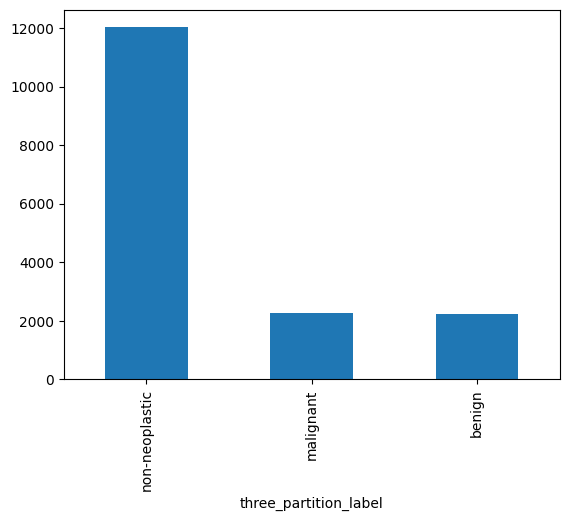

In [24]:
df["three_partition_label"].value_counts().plot(kind="bar")

To simplify the problem, we decided to study a binary classification Malignant/Benign. The non-neoplastic class will not be studied for now. 

We will only keep images from Malignant ans Benign classes. 

In [ ]:
# Keep only benign + malignant

# 1) Filter to binary classes
df_binary = df[df["three_partition_label"].isin(["malignant", "benign"])].copy()
df_binary = df_binary.reset_index(drop=True)

# 2) Distribution (counts + percentages)
counts = df_binary["three_partition_label"].value_counts()
perc = df_binary["three_partition_label"].value_counts(normalize=True) * 100

print("Binary dataset size:", len(df_binary))
print("\nCounts:\n", counts)
print("\nPercentages (%):\n", perc.round(2))

Binary dataset size: 4491

Counts:
 three_partition_label
malignant    2260
benign       2231
Name: count, dtype: int64

Percentages (%):
 three_partition_label
malignant    50.32
benign       49.68
Name: proportion, dtype: float64


We observe that the classes are well balanced so there is no need to implement methods to balance the classes

In [ ]:
IMG_SIZE = 256

val_transforms = A.Compose([
    # 1. Resize longest side to 256 (maintains aspect ratio)
    A.LongestMaxSize(max_size=IMG_SIZE),
    
    # 2. Pad remaining areas with zeros (black) to reach 256x256
    A.PadIfNeeded(
        min_height=IMG_SIZE, 
        min_width=IMG_SIZE, 
        border_mode=cv2.BORDER_CONSTANT, 
        value=0
    ),
    
    # 3. Normalize (ImageNet stats) & Convert to Tensor
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

In [ ]:
class FitzpatrickBinaryDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df_binary = dataframe.reset_index(drop=True)
        self.transform = transform
        
        # STRICT BINARY MAPPING
        self.label_map = {
            'benign': 0,
            'malignant': 1
        }

    def __len__(self):
        return len(self.df_binary)

    def __getitem__(self, idx):
        # 1. Get the path (ensure it is a string for cv2)
        img_path = str(self.df_binary.iloc[idx]["path"])
        label_str = self.df_binary.iloc[idx]["three_partition_label"]
        
        # 2. Load Image
        image = cv2.imread(img_path)
        
        if image is None:
            # Simple error handling: print and skip (or handle as needed)
            print(f"Warning: Could not load {img_path}")
            # Return a dummy tensor or handle index skipping (advanced)
            # For now, we'll assume data is clean since we filtered by df['downloaded']
            return torch.zeros((3, 256, 256)), torch.tensor(0)

        # 3. Convert BGR (OpenCV default) to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # 4. Apply Transforms (Pad & Resize)
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        # 5. Get Label
        label = torch.tensor(self.label_map[label_str], dtype=torch.long)

        return image, label

# --- Define the Transform (Pad & Resize to 256x256) ---
val_transforms = A.Compose([
    A.LongestMaxSize(max_size=256),
    A.PadIfNeeded(min_height=256, min_width=256, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

In [ ]:
# Create the dataset
dataset = FitzpatrickBinaryDataset(dataframe=df_binary, transform=val_transforms)

# Create the loader
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0) 
# Note: num_workers=0 is safer on Windows if you get multiprocessing errors

# Verify one batch
images, labels = next(iter(dataloader))
print(f"Images shape: {images.shape}")  # Should be [32, 3, 256, 256]
print(f"Labels: {labels}")              # Should be a mix of 0s and 1s